## 📦 Cell 1: Imports

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
from sklearn.feature_selection import mutual_info_classif
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

## 📊 Cell 2: STEP 1 — Data Collection

In [15]:
print("=" * 80)
print("📊 STEP 1: DATA COLLECTION")
print("=" * 80)

tickers = {'Gold': 'GC=F', 'DXY': 'DX-Y.NYB', 'VIX': '^VIX', 'SP500': '^GSPC'}
data_dict = {}
first_index = None

for name, ticker in tickers.items():
    print(f"Downloading {name} ({ticker})...")
    df = yf.download(ticker, period='2y', interval='1h', progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if df.empty:
        print(f"⚠️ Warning: No data found for {ticker}")
        continue

    if first_index is None:
        first_index = df.index

    data_dict[f'{name}_Close'] = df['Close'].squeeze()

    if name == 'Gold':
        data_dict['Gold_High'] = df['High'].squeeze()
        data_dict['Gold_Low'] = df['Low'].squeeze()
        data_dict['Gold_Open'] = df['Open'].squeeze()
        data_dict['Gold_Volume'] = df['Volume'].squeeze()

data = pd.DataFrame(data_dict, index=first_index).ffill().dropna()
print(f"✅ Data loaded successfully. Shape: {data.shape}")

# ตรวจสอบสัดส่วนแท่งที่ Volume = 0 (ต้นตอของ inf ใน pct_change)
zero_vol_ratio = (data['Gold_Volume'] == 0).mean()
print(f"ℹ️ สัดส่วนแท่งที่ Gold_Volume = 0: {zero_vol_ratio:.2%}")

📊 STEP 1: DATA COLLECTION
✅ Data loaded successfully. Shape: (10390, 8)
ℹ️ สัดส่วนแท่งที่ Gold_Volume = 0: 3.52%


## 🔧 Cell 3: STEP 2 — ICT Pattern Functions (FVG / Order Block / BOS-CHoCH)

In [16]:
def detect_fvg(df):
    high = df['Gold_High'].values
    low = df['Gold_Low'].values

    bullish_fvg = np.zeros(len(df))
    bearish_fvg = np.zeros(len(df))
    fvg_size = np.zeros(len(df))

    for i in range(2, len(df)):
        if low[i] > high[i-2]:
            bullish_fvg[i] = 1
            fvg_size[i] = low[i] - high[i-2]
        elif high[i] < low[i-2]:
            bearish_fvg[i] = 1
            fvg_size[i] = low[i-2] - high[i]

    return pd.DataFrame({
        'Bullish_FVG': bullish_fvg,
        'Bearish_FVG': bearish_fvg,
        'FVG_Size': fvg_size,
        'FVG_Net': bullish_fvg - bearish_fvg
    }, index=df.index)


def detect_order_block(df, lookback=10):
    high = df['Gold_High'].values
    low = df['Gold_Low'].values
    close = df['Gold_Close'].values
    open_price = df['Gold_Open'].values

    bullish_ob = np.zeros(len(df))
    bearish_ob = np.zeros(len(df))

    for i in range(lookback, len(df)):
        swing_high = np.max(high[i-lookback:i])
        swing_low = np.min(low[i-lookback:i])

        if close[i] > open_price[i] and close[i] > swing_high:
            for j in range(i-1, max(i-lookback, 0), -1):
                if close[j] < open_price[j]:
                    bullish_ob[i] = 1
                    break
        elif close[i] < open_price[i] and close[i] < swing_low:
            for j in range(i-1, max(i-lookback, 0), -1):
                if close[j] > open_price[j]:
                    bearish_ob[i] = 1
                    break

    return pd.DataFrame({
        'Bullish_OB': bullish_ob,
        'Bearish_OB': bearish_ob,
        'OB_Net': bullish_ob - bearish_ob
    }, index=df.index)


def detect_bos_choch(df, lookback=20):
    high = df['Gold_High'].values
    low = df['Gold_Low'].values
    close = df['Gold_Close'].values

    bos_bullish = np.zeros(len(df))
    bos_bearish = np.zeros(len(df))
    choch_bullish = np.zeros(len(df))
    choch_bearish = np.zeros(len(df))

    for i in range(lookback, len(df)):
        swing_high = np.max(high[i-lookback:i-1])
        swing_low = np.min(low[i-lookback:i-1])
        prev_trend = np.polyfit(range(lookback), close[i-lookback:i], 1)[0]

        if close[i] > swing_high and prev_trend > 0:
            bos_bullish[i] = 1
        elif close[i] < swing_low and prev_trend < 0:
            bos_bearish[i] = 1
        elif close[i] > swing_high and prev_trend < 0:
            choch_bullish[i] = 1
        elif close[i] < swing_low and prev_trend > 0:
            choch_bearish[i] = 1

    return pd.DataFrame({
        'BOS_Bullish': bos_bullish,
        'BOS_Bearish': bos_bearish,
        'CHoCH_Bullish': choch_bullish,
        'CHoCH_Bearish': choch_bearish,
        'Structure_Score': (bos_bullish + choch_bullish) - (bos_bearish + choch_bearish)
    }, index=df.index)


def detect_candle_patterns(df):
    open_price = df['Gold_Open'].values
    high = df['Gold_High'].values
    low = df['Gold_Low'].values
    close = df['Gold_Close'].values

    body = np.abs(close - open_price)
    upper_shadow = high - np.maximum(open_price, close)
    lower_shadow = np.minimum(open_price, close) - low
    total_range = high - low
    total_range = np.where(total_range == 0, 1e-10, total_range)

    patterns = {}

    bullish_engulfing = np.zeros(len(df))
    bearish_engulfing = np.zeros(len(df))
    for i in range(1, len(df)):
        if (close[i-1] < open_price[i-1] and close[i] > open_price[i] and
            body[i] > body[i-1] and open_price[i] <= close[i-1] and close[i] >= open_price[i-1]):
            bullish_engulfing[i] = 1
        elif (close[i-1] > open_price[i-1] and close[i] < open_price[i] and
              body[i] > body[i-1] and open_price[i] >= close[i-1] and close[i] <= open_price[i-1]):
            bearish_engulfing[i] = 1

    patterns['Bullish_Engulfing'] = bullish_engulfing
    patterns['Bearish_Engulfing'] = bearish_engulfing

    hammer = np.zeros(len(df))
    shooting_star = np.zeros(len(df))
    for i in range(len(df)):
        if (lower_shadow[i] > 2 * body[i] and upper_shadow[i] < body[i] and body[i] > 0):
            hammer[i] = 1
        elif (upper_shadow[i] > 2 * body[i] and lower_shadow[i] < body[i] and body[i] > 0):
            shooting_star[i] = 1

    patterns['Hammer'] = hammer
    patterns['Shooting_Star'] = shooting_star
    patterns['Doji'] = np.where(body < 0.1 * total_range, 1, 0)

    inside_bar = np.zeros(len(df))
    outside_bar = np.zeros(len(df))
    for i in range(1, len(df)):
        if high[i] < high[i-1] and low[i] > low[i-1]:
            inside_bar[i] = 1
        if high[i] > high[i-1] and low[i] < low[i-1]:
            outside_bar[i] = 1

    patterns['Inside_Bar'] = inside_bar
    patterns['Outside_Bar'] = outside_bar
    patterns['Body_Ratio'] = body / total_range
    patterns['Upper_Shadow_Ratio'] = upper_shadow / total_range
    patterns['Lower_Shadow_Ratio'] = lower_shadow / total_range

    return pd.DataFrame(patterns, index=df.index)

print("ICT / candlestick pattern functions defined.")

ICT / candlestick pattern functions defined.


## 🔧 Cell 4: STEP 2 — Feature Engineering (`create_features`) — **แก้บั๊ก inf ตรงนี้**

In [17]:
def create_features_v2(df):
    feat = df.copy()
    
    # Traditional Indicators
    feat['Gold_RSI'] = ta.momentum.RSIIndicator(feat['Gold_Close'], window=14).rsi()
    feat['Gold_MACD'] = ta.trend.MACD(feat['Gold_Close']).macd()
    feat['Gold_MACD_Signal'] = ta.trend.MACD(feat['Gold_Close']).macd_signal()
    feat['Gold_BB_Width'] = (ta.volatility.BollingerBands(feat['Gold_Close']).bollinger_hband() - 
                             ta.volatility.BollingerBands(feat['Gold_Close']).bollinger_lband())
    feat['Gold_ATR'] = ta.volatility.AverageTrueRange(
        high=feat['Gold_High'], low=feat['Gold_Low'], 
        close=feat['Gold_Close'], window=14
    ).average_true_range()
    feat['Gold_ATR_Pct'] = feat['Gold_ATR'] / feat['Gold_Close'] * 100  # ✅ Normalize
    feat['Gold_Stoch'] = ta.momentum.StochasticOscillator(
        feat['Gold_High'], feat['Gold_Low'], feat['Gold_Close']
    ).stoch()
    
    # ✅ เปลี่ยน: ใช้ Return แทน SMA/EMA (ลด multicollinearity)
    for window in [4, 12, 24, 72]:  # 4h, 12h, 24h, 72h
        feat[f'Gold_Return_{window}'] = feat['Gold_Close'].pct_change(window)
    
    # Cross-asset
    feat['DXY_Return_12'] = feat['DXY_Close'].pct_change(12)
    feat['VIX_Return_12'] = feat['VIX_Close'].pct_change(12)
    feat['SP500_Return_12'] = feat['SP500_Close'].pct_change(12)
    
    # ICT Patterns
    print("  🔍 Detecting ICT patterns...")
    feat = pd.concat([feat, detect_fvg(df)], axis=1)
    feat = pd.concat([feat, detect_order_block(df, lookback=10)], axis=1)
    feat = pd.concat([feat, detect_bos_choch(df, lookback=20)], axis=1)
    
    print("  🕯️ Detecting candlestick patterns...")
    feat = pd.concat([feat, detect_candle_patterns(df)], axis=1)
    
    # Rolling ICT
    feat['FVG_Net_10'] = feat['FVG_Net'].rolling(10).sum()
    feat['OB_Net_20'] = (feat['Bullish_OB'] - feat['Bearish_OB']).rolling(20).sum()
    feat['Structure_Score_30'] = feat['Structure_Score'].rolling(30).sum()
    
    # 🎯 CRITICAL FIX: Target threshold 0.1% → 0.3%
    # ทองวิ่ง 0.3% ใน 3 ชม. = signal จริง ไม่ใช่ noise
    future_return = feat['Gold_Close'].shift(-3) / feat['Gold_Close'] - 1
    feat['Target'] = np.select(
        [future_return > 0.003, future_return < -0.003],  # ✅ 0.3%
        [1, -1],
        default=0
    )
    
    feat = feat.replace([np.inf, -np.inf], np.nan).dropna()
    return feat

df_features = create_features_v2(data)
print(f"✅ Features: {df_features.shape}")

# ตรวจสอบ class distribution ใหม่
print("\n📊 Class Distribution (หลังปรับ threshold 0.3%):")
target_counts = df_features['Target'].value_counts().sort_index()
for cls, count in target_counts.items():
    label = {-1: 'Down', 0: 'Neutral', 1: 'Up'}[cls]
    print(f"  {label} ({cls}): {count} ({count/len(df_features)*100:.1f}%)")




  🔍 Detecting ICT patterns...
  🕯️ Detecting candlestick patterns...
✅ Features: (10318, 48)

📊 Class Distribution (หลังปรับ threshold 0.3%):
  Down (-1): 2015 (19.5%)
  Neutral (0): 5994 (58.1%)
  Up (1): 2309 (22.4%)


In [18]:
# ================= 3. FEATURE SELECTION (ปรับปรุง) =================
print("\n🎯 STEP 3: Feature Selection...")

cols_to_drop = ['Target', 'Gold_Close', 'Gold_High', 'Gold_Low', 'Gold_Open',
                'Gold_Volume', 'DXY_Close', 'VIX_Close', 'SP500_Close']
X = df_features.drop(columns=[c for c in cols_to_drop if c in df_features.columns])
y = df_features['Target'].map({-1: 0, 0: 1, 1: 2}).astype(int)

# ✅ ใช้ mutual_info_classif แทน f_classif (ดีกับ non-linear relationships)
mi_scores = mutual_info_classif(X.values, y, random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

# ✅ ลด features จาก 30 → 15 (ลด multicollinearity)
k_features = 15
selected_feature_names = mi_df.head(k_features)['feature'].tolist()
X_selected_df = X[selected_feature_names]

print(f"✅ Top {k_features} Features (by Mutual Information):")
for i, row in mi_df.head(k_features).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['mi_score']:.4f}")




🎯 STEP 3: Feature Selection...
✅ Top 15 Features (by Mutual Information):
  6. Gold_ATR_Pct: 0.0379
  5. Gold_ATR: 0.0327
  4. Gold_BB_Width: 0.0278
  2. Gold_MACD: 0.0206
  3. Gold_MACD_Signal: 0.0165
  1. Gold_RSI: 0.0159
  11. Gold_Return_72: 0.0120
  9. Gold_Return_12: 0.0120
  23. BOS_Bearish: 0.0118
  10. Gold_Return_24: 0.0104
  38. OB_Net_20: 0.0101
  24. CHoCH_Bullish: 0.0096
  34. Body_Ratio: 0.0090
  32. Inside_Bar: 0.0084
  13. VIX_Return_12: 0.0081


In [20]:
# ================= 4. SEQUENCE + SPLIT =================
print("\n🚀 STEP 4: Sequence Creation...")

def create_sequences(X, y, time_steps=48):  # ✅ เพิ่มเป็น 48 (2 วัน)
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 48
X_seq, y_seq = create_sequences(X_selected_df, y, time_steps)

# ✅ Walk-forward split (80/10/10)
split1 = int(len(X_seq) * 0.8)
split2 = int(len(X_seq) * 0.9)

X_train, y_train = X_seq[:split1], y_seq[:split1]
X_val, y_val = X_seq[split1:split2], y_seq[split1:split2]
X_test, y_test = X_seq[split2:], y_seq[split2:]

print(f"📈 Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ✅ ใช้ StandardScaler แทน MinMaxScaler (เหมาะกับ LSTM + BatchNorm)
scaler = StandardScaler()
n_samples, n_timesteps, n_features = X_train.shape

X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(np.unique(y_train), class_weights)}
print(f"⚖️ Class weights: {class_weight_dict}")



🚀 STEP 4: Sequence Creation...
📈 Train: 8216, Val: 1027, Test: 1027
⚖️ Class weights: {0: 1.8367985691929354, 1: 0.5592539650125927, 2: 1.4981765134938}


In [21]:
# ================= 5. IMPROVED MODEL ARCHITECTURE =================
print("\n🧠 STEP 5: Building Improved Models...")

def build_improved_lstm(input_shape):
    """✅ สถาปัตยกรรมใหม่: เล็กลง + BatchNorm + L2 Regularization"""
    model = Sequential([
        Input(shape=input_shape),
        
        # Block 1
        LSTM(32, activation='tanh', return_sequences=True,  # ✅ tanh ดีกว่า relu สำหรับ LSTM
             kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Block 2
        LSTM(16, activation='tanh', return_sequences=False,
             kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Dense
        Dense(8, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        
        # ✅ เอา label_smoothing ออก (ไม่รองรับใน TF เวอร์ชันนี้)
        Dense(3, activation='softmax')
    ])
    
    # ✅ ใช้ sparse_categorical_crossentropy แบบปกติ
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_improved_bilstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(32, activation='tanh', return_sequences=True,
                          kernel_regularizer=l2(1e-4))),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(16, activation='tanh', return_sequences=False,
                          kernel_regularizer=l2(1e-4))),
        BatchNormalization(),
        Dropout(0.3),
        Dense(8, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dense(3, activation='softmax')
    ])
    
    # ✅ ใช้ sparse_categorical_crossentropy แบบปกติ
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

input_shape = (time_steps, n_features)
lstm_model = build_improved_lstm(input_shape)
bilstm_model = build_improved_bilstm(input_shape)

# ✅ Callbacks ที่เข้มงวดขึ้น
early_stopping = EarlyStopping(
    monitor='val_loss', patience=20, min_delta=0.0005,
    restore_best_weights=True, mode='min', verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1
)




🧠 STEP 5: Building Improved Models...


In [22]:
# ================= 6. TRAINING =================
print("\n🏋️ STEP 6: Training...")

print("\n🔹 Training Improved LSTM...")
history_lstm = lstm_model.fit(
    X_train_scaled, y_train, epochs=100, batch_size=64,  # ✅ batch ใหญ่ขึ้น
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr], verbose=1
)

print("\n🔹 Training Improved BiLSTM...")
history_bilstm = bilstm_model.fit(
    X_train_scaled, y_train, epochs=100, batch_size=64,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr], verbose=1
)




🏋️ STEP 6: Training...

🔹 Training Improved LSTM...
Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.3989 - loss: 1.1392 - val_accuracy: 0.2833 - val_loss: 1.1173 - learning_rate: 0.0010
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4485 - loss: 1.0902 - val_accuracy: 0.2970 - val_loss: 1.1391 - learning_rate: 0.0010
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4567 - loss: 1.0763 - val_accuracy: 0.2921 - val_loss: 1.1486 - learning_rate: 0.0010
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4653 - loss: 1.0729 - val_accuracy: 0.2941 - val_loss: 1.1593 - learning_rate: 0.0010
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4860 - loss: 1.0608 - val_accuracy: 0.2853 - val_loss: 1.1615 - learning_rate: 0.0010
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4848 - loss: 1.0561 - val_accuracy: 0.2707 - val_loss: 1.1820 - learning_rate: 0.0010
Epoch 7/100
129/129 ━━━

In [23]:
# ================= 7. ENSEMBLE (GradientBoosting แทน RandomForest) =================
print("\n🧩 STEP 7: Stacking Ensemble...")

lstm_pred = lstm_model.predict(X_test_scaled, verbose=0)
bilstm_pred = bilstm_model.predict(X_test_scaled, verbose=0)

lstm_pred_class = np.argmax(lstm_pred, axis=1)
bilstm_pred_class = np.argmax(bilstm_pred, axis=1)

stacked_train = np.hstack([
    lstm_model.predict(X_train_scaled, verbose=0),
    bilstm_model.predict(X_train_scaled, verbose=0)
])
stacked_test = np.hstack([
    lstm_model.predict(X_test_scaled, verbose=0),
    bilstm_model.predict(X_test_scaled, verbose=0)
])

# ✅ GradientBoosting มักดีกว่า RandomForest สำหรับ stacking
meta_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
meta_model.fit(stacked_train, y_train)
ensemble_pred = meta_model.predict(stacked_test)


🧩 STEP 7: Stacking Ensemble...



📊 FINAL RESULTS

🎯 Accuracy Comparison:
  LSTM:      0.3126
  BiLSTM:    0.3223
  Ensemble:  0.4849

📋 Classification Report (Ensemble):
              precision    recall  f1-score   support

        Down       0.24      0.15      0.19       234
     Neutral       0.55      0.79      0.65       546
          Up       0.31      0.13      0.18       247

    accuracy                           0.48      1027
   macro avg       0.37      0.36      0.34      1027
weighted avg       0.42      0.48      0.43      1027



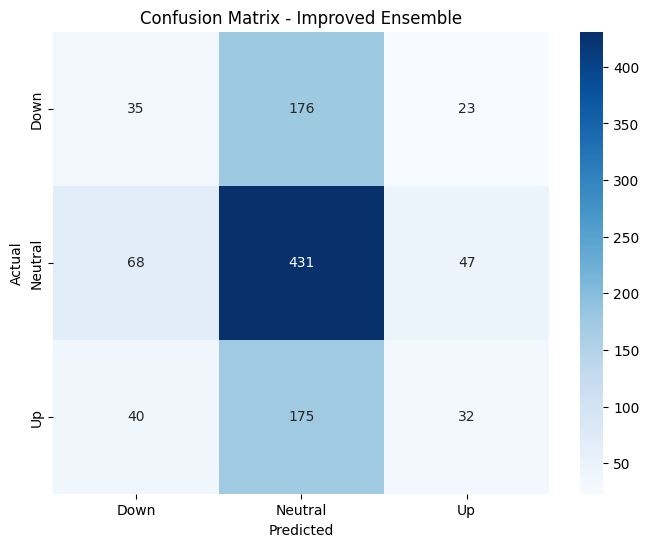

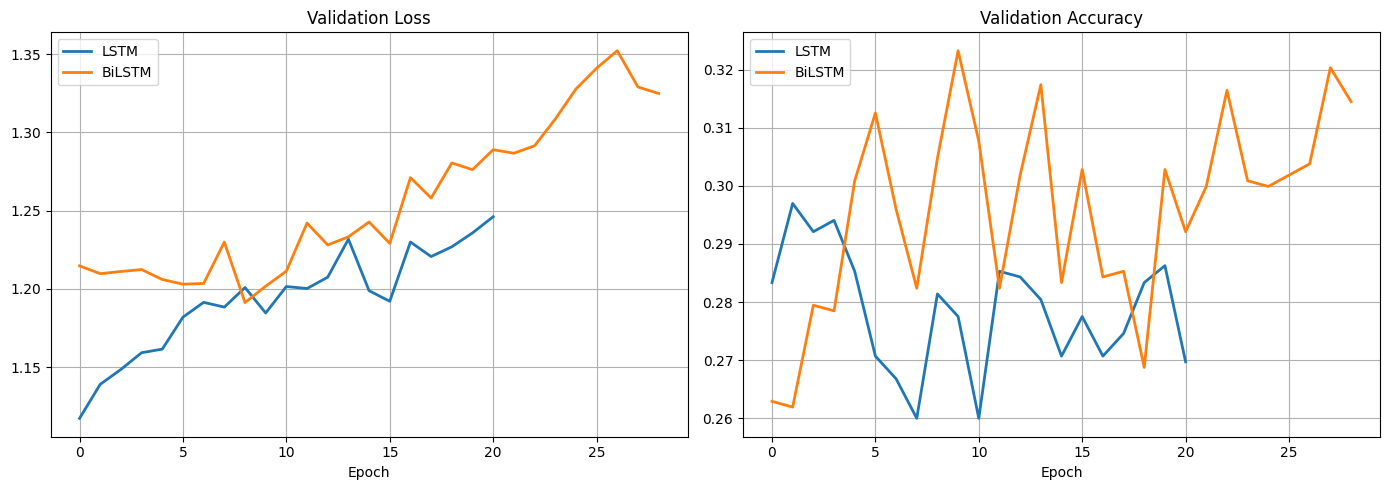

In [25]:
# ================= 8. RESULTS =================
print("\n" + "=" * 80)
print("📊 FINAL RESULTS")
print("=" * 80)

print(f"\n🎯 Accuracy Comparison:")
print(f"  LSTM:      {accuracy_score(y_test, lstm_pred_class):.4f}")
print(f"  BiLSTM:    {accuracy_score(y_test, bilstm_pred_class):.4f}")
print(f"  Ensemble:  {accuracy_score(y_test, ensemble_pred):.4f}")

print(f"\n📋 Classification Report (Ensemble):")
print(classification_report(y_test, ensemble_pred, 
                            target_names=['Down', 'Neutral', 'Up']))

# Confusion Matrix
cm = confusion_matrix(y_test, ensemble_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Neutral', 'Up'],
            yticklabels=['Down', 'Neutral', 'Up'])
plt.title('Confusion Matrix - Improved Ensemble')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_lstm.history['val_loss'], label='LSTM', linewidth=2)
axes[0].plot(history_bilstm.history['val_loss'], label='BiLSTM', linewidth=2)
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_lstm.history['val_accuracy'], label='LSTM', linewidth=2)
axes[1].plot(history_bilstm.history['val_accuracy'], label='BiLSTM', linewidth=2)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [26]:
# ================= 9. SAVE MODELS =================
os.makedirs('models', exist_ok=True)
lstm_model.save('models/improved_lstm.keras')
bilstm_model.save('models/improved_bilstm.keras')
joblib.dump(meta_model, 'models/improved_meta.pkl')
joblib.dump(scaler, 'models/improved_scaler.pkl')
joblib.dump(selected_feature_names, 'models/improved_features.pkl')
joblib.dump({'time_steps': time_steps, 'threshold': 0.003}, 'models/improved_config.pkl')

print("\n✅ Improved models saved!")


✅ Improved models saved!


In [28]:
# ================= 💾 SAVE DATA TO CSV =================
print("\n Saving data splits to CSV...")

os.makedirs('data', exist_ok=True)

# แปลงกลับเป็น DataFrame เพื่อ save
def sequence_to_df(X_seq, y_seq, feature_names, start_idx):
    """แปลง sequence กลับเป็น DataFrame แบบ row-per-sample"""
    # ใช้ข้อมูลล่าสุดของ sequence (timestep สุดท้าย) เป็นตัวแทน
    last_timestep = X_seq[:, -1, :]  # shape: (n_samples, n_features)
    df = pd.DataFrame(last_timestep, columns=feature_names)
    df['Target'] = y_seq
    df['Original_Index'] = range(start_idx, start_idx + len(y_seq))
    return df

# คำนวณ index เริ่มต้นของแต่ละ set
train_start = 0
val_start = len(y_train)
test_start = len(y_train) + len(y_val)

# Save แต่ละ set
train_df = sequence_to_df(X_train, y_train, selected_feature_names, train_start)
val_df = sequence_to_df(X_val, y_val, selected_feature_names, val_start)
test_df = sequence_to_df(X_test, y_test, selected_feature_names, test_start)

train_df.to_csv('data/train_data.csv', index=False)
val_df.to_csv('data/val_data.csv', index=False)
test_df.to_csv('data/test_data.csv', index=False)

# Save ข้อมูลดิบ (ก่อน feature selection) ด้วย
df_features.to_csv('data/full_features.csv')
data.to_csv('data/raw_data.csv')

print(f"✅ Saved to data/ folder:")
print(f"   📄 train_data.csv: {len(train_df)} rows")
print(f"   📄 val_data.csv:   {len(val_df)} rows")
print(f"   📄 test_data.csv:  {len(test_df)} rows")
print(f"   📄 full_features.csv: {len(df_features)} rows")
print(f"   📄 raw_data.csv: {len(data)} rows")


 Saving data splits to CSV...
✅ Saved to data/ folder:
   📄 train_data.csv: 8216 rows
   📄 val_data.csv:   1027 rows
   📄 test_data.csv:  1027 rows
   📄 full_features.csv: 10318 rows
   📄 raw_data.csv: 10390 rows
